# Image preprocessing

In [22]:
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/dissertation')
else:
    PROJECT_ROOT = Path('..').resolve()

DATA_ROOT = PROJECT_ROOT / 'CGMacros'

PROCESSED_DIR = PROJECT_ROOT / 'processed_data' / 'processed_5min'

print(f"IN_COLAB={IN_COLAB}")
print(f"REPO_ROOT={PROJECT_ROOT}")
print(f"DATA_ROOT={DATA_ROOT}")
print(f"PROCESSED_DIR={PROCESSED_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB=True
REPO_ROOT=/content/drive/MyDrive/dissertation
DATA_ROOT=/content/drive/MyDrive/dissertation/CGMacros
PROCESSED_DIR=/content/drive/MyDrive/dissertation/processed_data/processed_5min


In [8]:
import json
import pickle

import numpy as np
import torch
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
from tqdm.auto import tqdm

In [20]:
SPLITS = ['train', 'val', 'test']
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

PREPROC_DIR = PROJECT_ROOT / 'processed_data' / 'img_preprocessing'
PREPROC_DIR.mkdir(parents=True, exist_ok=True)

class SquarePad:
    def __init__(self, size: int = IMG_SIZE, fill: int = 0):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        w, h = img.size
        diff = abs(w - h)
        if w < h:
            pad = (diff // 2, 0, diff - diff // 2, 0)
        else:
            pad = (0, diff // 2, 0, diff - diff // 2)
        img = TF.pad(img, pad, fill=self.fill)
        return TF.resize(img, [self.size, self.size])


IMG_TRANSFORM = transforms.Compose([
    SquarePad(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## Collect unique images

In [11]:
def image_key(sample: dict) -> str:
    return f"{sample['participant_id']}/{Path(sample['image_path']).name}"

candidate_paths = {}
n_rows_with_image = 0
per_split_counts = {}

for split in SPLITS:
    with open(PROCESSED_DIR / f'{split}.pkl', 'rb') as f:
        samples = pickle.load(f)
    split_n_img = 0
    for s in samples:
        if not s['has_image']:
            continue
        n_rows_with_image += 1
        split_n_img += 1
        key = image_key(s)
        if key not in candidate_paths:
            candidate_paths[key] = DATA_ROOT / s['participant_id'] / 'photos' / Path(s['image_path']).name
    per_split_counts[split] = {'n_samples': len(samples), 'n_with_image': split_n_img}

print('per-split sample counts:')
for split, c in per_split_counts.items():
    print(f"  {split:>5}: {c['n_samples']:>6} samples, {c['n_with_image']:>5} with image "
          f"({100 * c['n_with_image'] / c['n_samples']:.1f}%)")
print(f'\ntotal has_image sample-rows (all splits): {n_rows_with_image}')
print(f'unique candidate images: {len(candidate_paths)}')

unique_images = {}
failed_images = {}

for key, path in tqdm(candidate_paths.items(), desc='verifying images open'):
    try:
        Image.open(path).convert('RGB')
        unique_images[key] = path
    except FileNotFoundError:
        failed_images[key] = {'path': str(path), 'reason': 'missing from disk'}
    except Exception as e:
        failed_images[key] = {'path': str(path), 'reason': f'{type(e).__name__}: {e}'}

print(f'\nopenable: {len(unique_images)}/{len(candidate_paths)} unique images')
if failed_images:
    fail_path = PREPROC_DIR / 'image_load_failures.json'
    with open(fail_path, 'w') as f:
        json.dump(failed_images, f, indent=2)
    print(f'FAILED to open {len(failed_images)} images -- saved details to {fail_path}')
    for k, info in list(failed_images.items())[:5]:
        print(f"  {k}: {info['reason']}")
    print('  these sample-rows are still has_image=True in the pkl -- effectively no usable image '
          'for the image branch, and the coverage check further down reports them separately from '
          'genuinely photo-less samples.')
else:
    print('all candidate images opened successfully -- no missing/corrupted files')

per-split sample counts:
  train:  83532 samples, 23774 with image (28.5%)
    val:  16739 samples,  4272 with image (25.5%)
   test:  16842 samples,  5142 with image (30.5%)

total has_image sample-rows (all splits): 33188
unique candidate images: 1517


verifying images open:   0%|          | 0/1517 [00:00<?, ?it/s]


openable: 1517/1517 unique images
all candidate images opened successfully -- no missing/corrupted files


### Sample output: one concrete image-bearing row


example sample dict (image-bearing row):
  participant_id: CGMacros-001
  timestamp: 2020-05-01 14:24:00
  image_path: /content/drive/MyDrive/dissertation/CGMacros/CGMacros-001/photos/00000005-PHOTO-2020-5-1-14-23-0.jpg
  has_image: True
  time_since_meal: 1.0
  cgm_sequence shape: (24,)  dtype: float32

resolved image key:  CGMacros-001/00000005-PHOTO-2020-5-1-14-23-0.jpg
resolved disk path:  /content/drive/MyDrive/dissertation/CGMacros/CGMacros-001/photos/00000005-PHOTO-2020-5-1-14-23-0.jpg


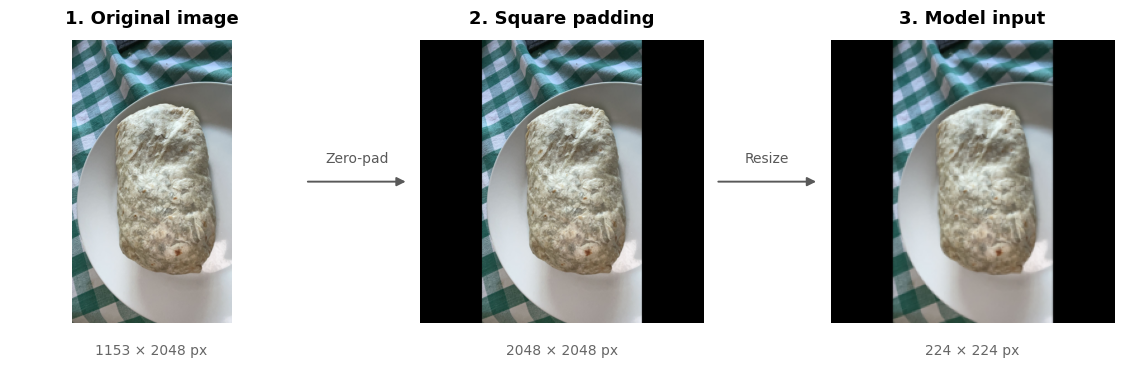

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

with open(PROCESSED_DIR / 'train.pkl', 'rb') as f:
    _demo_samples = pickle.load(f)

_demo_sample = next(s for s in _demo_samples if s['has_image'])

print('example sample dict (image-bearing row):')
for k in ['participant_id', 'timestamp', 'image_path', 'has_image', 'time_since_meal']:
    print(f'  {k}: {_demo_sample[k]}')

print(f"  cgm_sequence shape: {_demo_sample['cgm_sequence'].shape}  "
      f"dtype: {_demo_sample['cgm_sequence'].dtype}")

_demo_key = image_key(_demo_sample)
_demo_path = unique_images[_demo_key]

print(f'\nresolved image key:  {_demo_key}')
print(f'resolved disk path:  {_demo_path}')

_demo_img = Image.open(_demo_path).convert('RGB')
_orig_w, _orig_h = _demo_img.size

# Replicate SquarePad step-by-step so that padding and resizing can be visualised separately.
_diff = abs(_orig_w - _orig_h)

if _orig_w < _orig_h:
    _pad_box = (_diff // 2, 0, _diff - _diff // 2, 0)
else:
    _pad_box = (0, _diff // 2, 0, _diff - _diff // 2)

_demo_square = TF.pad(_demo_img, _pad_box, fill=0)
_sq_w, _sq_h = _demo_square.size
_demo_resized = TF.resize(_demo_square, [IMG_SIZE, IMG_SIZE])


# ── Visualise preprocessing ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(12, 4.6))
fig.subplots_adjust(left=0.04, right=0.96, top=0.86, bottom=0.16, wspace=0.45)

for ax in axes:
    ax.set_box_aspect(1)

axes[0].imshow(_demo_img)
axes[0].set_title('1. Original image', fontsize=13, fontweight='semibold', pad=12)
axes[0].text(0.5, -0.07, f'{_orig_w} × {_orig_h} px', transform=axes[0].transAxes,
             ha='center', va='top', fontsize=10, color='0.4')
axes[0].axis('off')

axes[1].imshow(_demo_square)
axes[1].set_title('2. Square padding', fontsize=13, fontweight='semibold', pad=12)
axes[1].text(0.5, -0.07, f'{_sq_w} × {_sq_h} px', transform=axes[1].transAxes,
             ha='center', va='top', fontsize=10, color='0.4')
axes[1].axis('off')

axes[2].imshow(_demo_resized)
axes[2].set_title('3. Model input', fontsize=13, fontweight='semibold', pad=12)
axes[2].text(0.5, -0.07, f'{IMG_SIZE} × {IMG_SIZE} px', transform=axes[2].transAxes,
             ha='center', va='top', fontsize=10, color='0.4')
axes[2].axis('off')

fig.canvas.draw()


# ── Add arrows between preprocessing stages ────────────────────────────────────

def add_between_arrow(ax_left, ax_right, label):
    box_l = ax_left.get_position()
    box_r = ax_right.get_position()

    x0, x1 = box_l.x1 + 0.01, box_r.x0 - 0.01
    y = (box_l.y0 + box_l.y1) / 2

    arrow = FancyArrowPatch(
        (x0, y), (x1, y), transform=fig.transFigure,
        arrowstyle='-|>', mutation_scale=13, linewidth=1.4, color='0.35')
    fig.add_artist(arrow)

    fig.text((x0 + x1) / 2, y + 0.035, label,
             ha='center', va='bottom', fontsize=10, color='0.35')


add_between_arrow(axes[0], axes[1], 'Zero-pad')
add_between_arrow(axes[1], axes[2], 'Resize')

plt.show()

## Apply and verify the preprocessing transform

In [18]:
transform_failures = {}
shape_set = set()
value_min, value_max = float('inf'), float('-inf')

for key, path in tqdm(unique_images.items(), desc='applying SquarePad+ToTensor+Normalize'):
    try:
        img = Image.open(path).convert('RGB')
        tensor = IMG_TRANSFORM(img)
    except Exception as e:
        transform_failures[key] = f'{type(e).__name__}: {e}'
        continue
    shape_set.add(tuple(tensor.shape))
    if not torch.isfinite(tensor).all():
        transform_failures[key] = 'non-finite values after transform (NaN/Inf)'
        continue
    value_min = min(value_min, tensor.min().item())
    value_max = max(value_max, tensor.max().item())

print(f'transformed {len(unique_images) - len(transform_failures)}/{len(unique_images)} images successfully')
print(f'output tensor shapes seen: {shape_set}')
print(f'value range across all transformed images: [{value_min:.2f}, {value_max:.2f}]')

if transform_failures:
    tf_fail_path = PREPROC_DIR / 'transform_failures.json'
    with open(tf_fail_path, 'w') as f:
        json.dump(transform_failures, f, indent=2)
    print(f'\n\u26a0\ufe0f {len(transform_failures)} images opened fine but failed the transform -- '
          f'saved to {tf_fail_path}, treat like image_load_failures.json (real data problem, not '
          f'a normal no-image sample):')
    for k, reason in list(transform_failures.items())[:5]:
        print(f'  {k}: {reason}')
else:
    print('\nevery openable image also passed the transform cleanly -- shape and value range consistent')

applying SquarePad+ToTensor+Normalize:   0%|          | 0/1517 [00:00<?, ?it/s]

transformed 1517/1517 images successfully
output tensor shapes seen: {(3, 224, 224)}
value range across all transformed images: [-2.12, 2.64]

every openable image also passed the transform cleanly -- shape and value range consistent


## Coverage check

In [21]:
all_known_failures = set(failed_images.keys()) | set(transform_failures.keys())
resolved_keys = set(unique_images.keys()) - set(transform_failures.keys())

n_no_meal = n_missing_image = n_known_failure = n_resolved = n_unexplained = 0
for split in SPLITS:
    with open(PROCESSED_DIR / f'{split}.pkl', 'rb') as f:
        samples = pickle.load(f)
    for s in samples:
        if not s['has_meal']:
            n_no_meal += 1
            continue
        if not s['has_image']:
            n_missing_image += 1
            continue
        key = image_key(s)
        if key in resolved_keys:
            n_resolved += 1
        elif key in all_known_failures:
            n_known_failure += 1
        else:
            n_unexplained += 1

status = 'OK' if n_unexplained == 0 else 'BUG -- unexplained gap, investigate'
print(f'no_meal={n_no_meal}  missing_image={n_missing_image}  resolved={n_resolved}  '
      f'known_failure={n_known_failure}  unexplained={n_unexplained}  [{status}]')

resolved_keys_path = PREPROC_DIR / 'resolved_image_keys.json'
with open(resolved_keys_path, 'w') as f:
    json.dump(sorted(resolved_keys), f, indent=2)
print(f'\nsaved {len(resolved_keys)} verified, transform-ready image keys to {resolved_keys_path}')
print('(paths are rebuildable from DATA_ROOT + key at experiment time -- nothing encoder-specific '
      'is cached here, per this notebook\'s scope)')

no_meal=82666  missing_image=1259  resolved=33188  known_failure=0  unexplained=0  [OK]

saved 1517 verified, transform-ready image keys to /content/drive/MyDrive/dissertation/processed_data/img_preprocessing/resolved_image_keys.json
(paths are rebuildable from DATA_ROOT + key at experiment time -- nothing encoder-specific is cached here, per this notebook's scope)


## Quantify missing-image cases

The `missing_image` bucket above (`has_meal=True`, `has_image=False`) is what any imputation
strategy for the image branch actually needs to cover -- not `no_meal`, which needs no image
signal at all. Broken down here by split and by whether the underlying cause is "never
photographed" vs "photographed but the file is missing/corrupted", since a fix for one wouldn't
touch the other. This cell only measures the gap; how to fill it is a separate, follow-up
modelling decision (a placeholder embedding, a learned "missing" token, something else).

In [23]:
missing_records = []
for split in SPLITS:
    with open(PROCESSED_DIR / f'{split}.pkl', 'rb') as f:
        samples = pickle.load(f)
    for s in samples:
        if s['has_meal'] and not s['has_image']:
            missing_records.append({
                'split': split,
                'participant_id': s['participant_id'],
                'timestamp': str(s['timestamp']),
                'time_since_meal': s['time_since_meal'],
            })

print(f'total missing_image samples: {len(missing_records)}')
for split in SPLITS:
    n_split_missing = sum(r['split'] == split for r in missing_records)
    with open(PROCESSED_DIR / f'{split}.pkl', 'rb') as f:
        n_split_total = len(pickle.load(f))
    print(f'  {split:>5}: {n_split_missing:>6} / {n_split_total} samples '
          f'({100 * n_split_missing / n_split_total:.1f}%)')

missing_path = PREPROC_DIR / 'missing_image_samples.json'
with open(missing_path, 'w') as f:
    json.dump(missing_records, f, indent=2)
print(f'\nsaved {len(missing_records)} missing-image sample records to {missing_path}')

total missing_image samples: 1259
  train:    851 / 83532 samples (1.0%)
    val:    384 / 16739 samples (2.3%)
   test:     24 / 16842 samples (0.1%)

saved 1259 missing-image sample records to /content/drive/MyDrive/dissertation/processed_data/img_preprocessing/missing_image_samples.json
